In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import streamlit as st
import pickle

In [2]:
data =pd.read_csv(r"C:\Users\riyuu\OneDrive\emplyoee atrrition project\project data.csv")

In [3]:
pd.set_option('display.max_columns',None) #o show all columns of a DataFrame when you print it.

In [4]:
data.head(3)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0


In [5]:
data.info  # check the data type


<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education Education

In [6]:
data.isnull().sum() # check total null valuess    .... as per result we do not have any null values
(data == " ") .sum()        # checking for blank string or values as per result we have o blank strings          

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
data['Department'].unique

<bound method Series.unique of 0                        Sales
1       Research & Development
2       Research & Development
3       Research & Development
4       Research & Development
                 ...          
1465    Research & Development
1466    Research & Development
1467    Research & Development
1468                     Sales
1469    Research & Development
Name: Department, Length: 1470, dtype: object>

In [8]:
s=(data['MonthlyIncome']==0).sum()
s

0

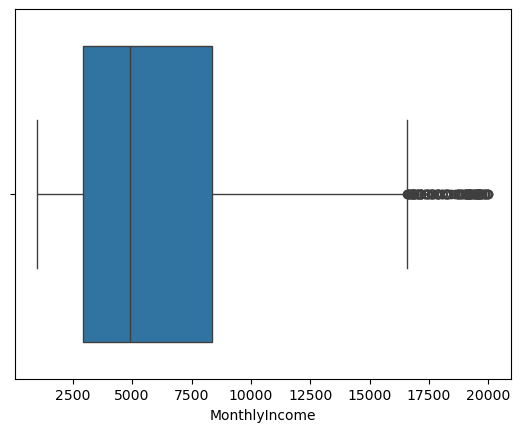

In [9]:
#checking outliers  
sns.boxplot(x=data['MonthlyIncome'])
plt.show()

C:\Users\riyuu\AppData\Local\Temp\ipykernel_13248\2732010063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Attrition',data=data , palette='Set2')


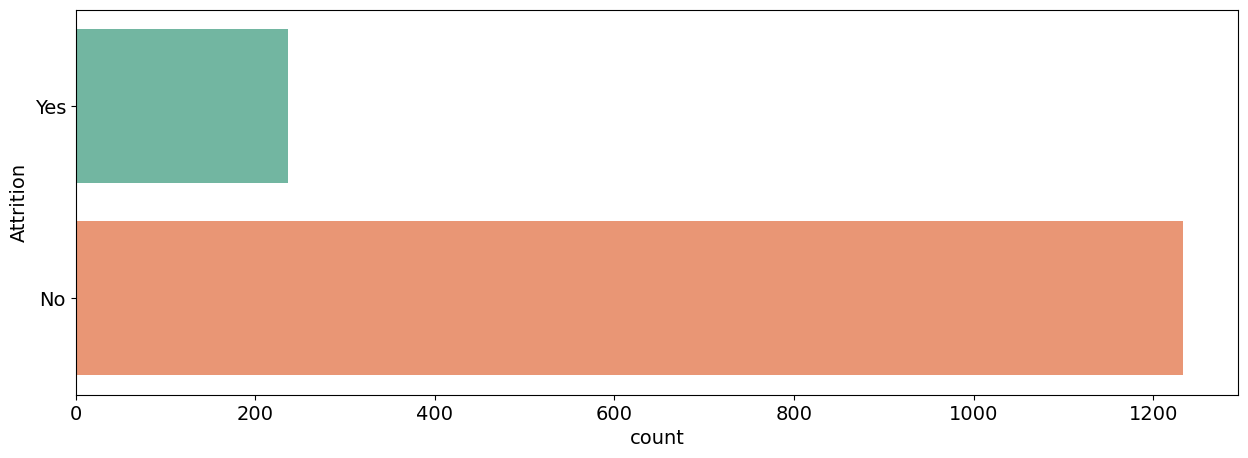

In [10]:
#TARGET COLUMN

plt.figure(figsize=(15,5))
plt.rc("font" , size=14)
sns.countplot(y='Attrition',data=data , palette='Set2')
plt.show()

#EPLORATRAY DATA ANALYSIS EDA

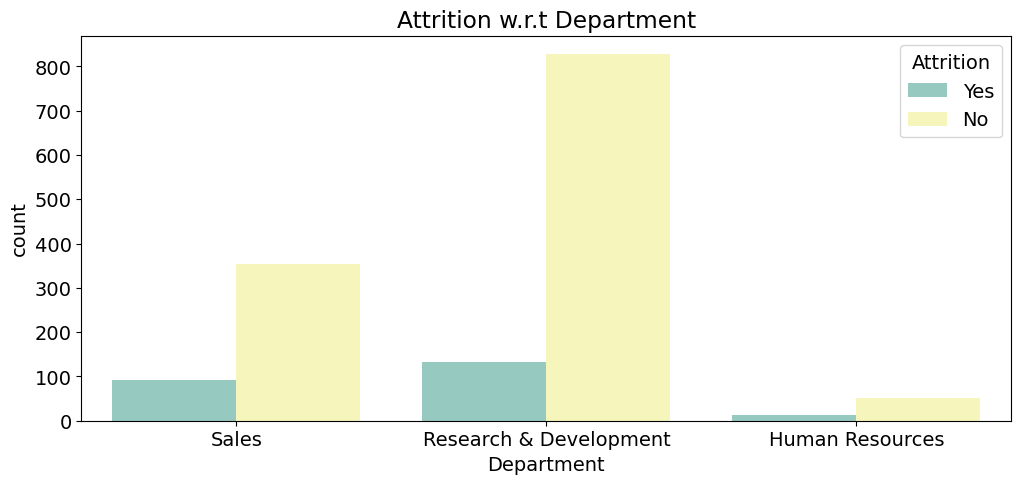

In [11]:
#DEPARTMENT WISE ATTRITION
plt.figure(figsize=(12,5))
sns.countplot(x='Department' , hue='Attrition' , data=data , palette='Set3')
plt.title("Attrition w.r.t Department")
plt.show()

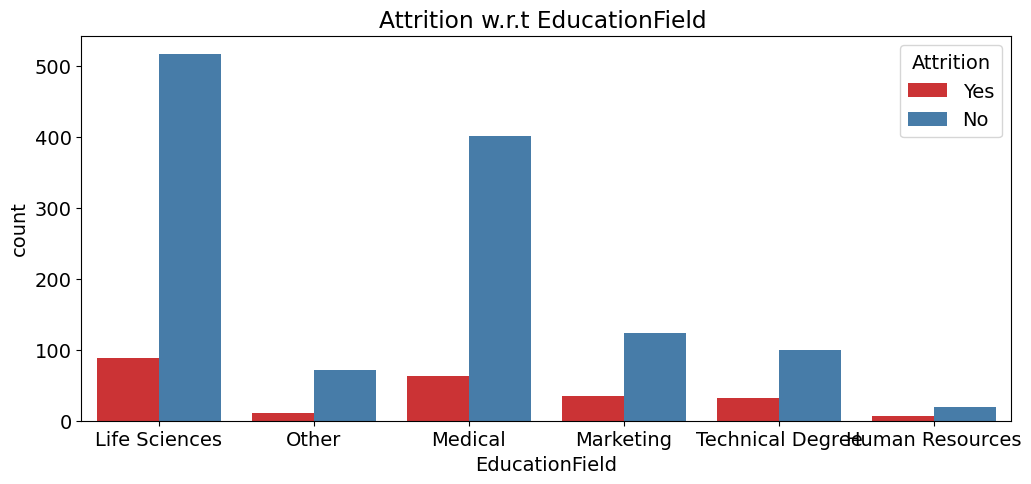

In [12]:
#EDUCATION FIELD  WISE ATTRITION
plt.figure(figsize=(12,5))
sns.countplot(x='EducationField' , hue='Attrition' , data=data , palette='Set1')
plt.title("Attrition w.r.t EducationField ")
plt.show()

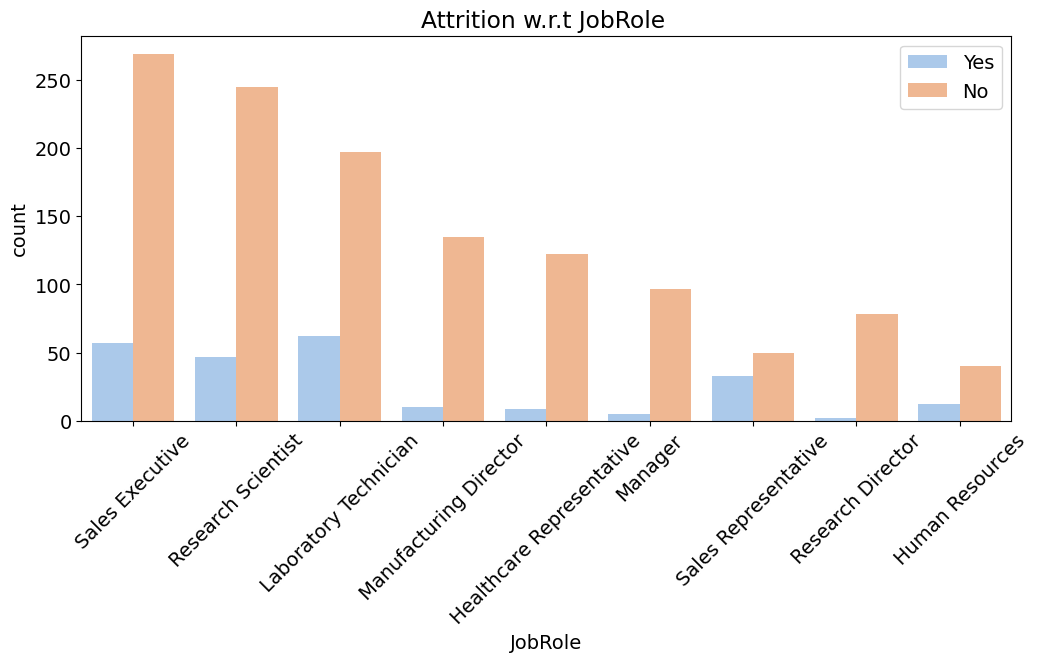

In [13]:
#job role WISE ATTRITION
plt.figure(figsize=(12,5))
sns.countplot(x='JobRole' , hue='Attrition' , data=data , palette='pastel')
plt.title("Attrition w.r.t JobRole ")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.show()

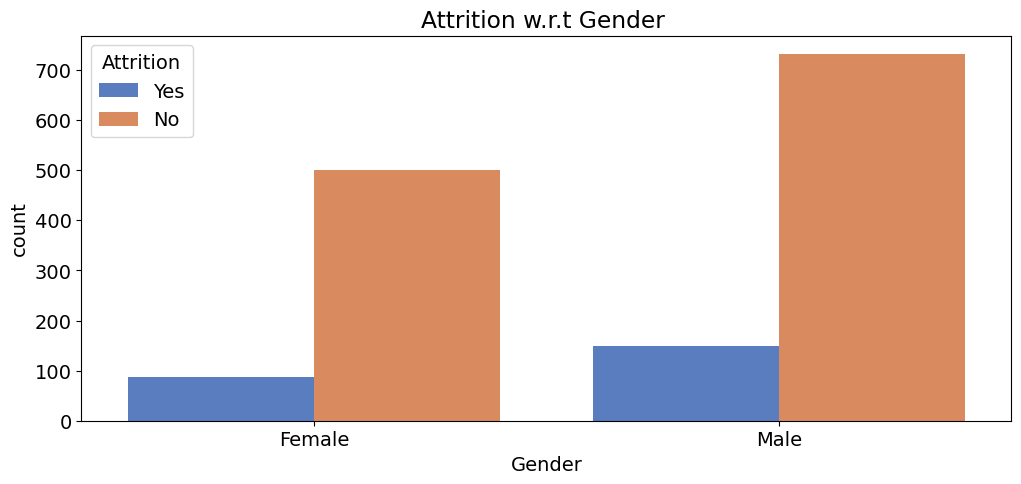

In [14]:
#Gender  WISE ATTRITION
plt.figure(figsize=(12,5))
sns.countplot(x='Gender' , hue='Attrition' , data=data , palette='muted')
plt.title("Attrition w.r.t Gender ")
plt.show()

In [15]:
data['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [16]:
data.groupby(['Gender','Attrition']).size()

Gender  Attrition
Female  No           501
        Yes           87
Male    No           732
        Yes          150
dtype: int64

C:\Users\riyuu\AppData\Local\Temp\ipykernel_13248\1744472543.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'], hist=False)


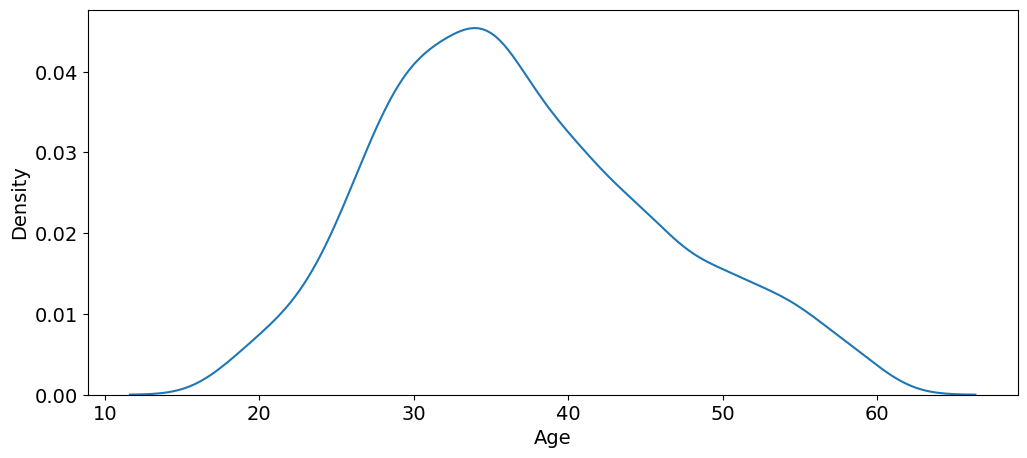

In [17]:
#DISTRIBUTION OF AGE 
plt.figure(figsize=(12,5))
sns.distplot(data['Age'], hist=False)
plt.show()


#LABEL CODING 
#MACHINE CANT UNDERSTAND AND CANNOT PREDICT TEXT DATA SO LABEL CODING METHOD CONVERT TEXT OR CATEGORIAL DAYA INTO NUMERIC

In [18]:
#target variable attrtitomn
data['Attrition']=data['Attrition'].replace({'No':0 , 'Yes':1})
data['Attrition']

C:\Users\riyuu\AppData\Local\Temp\ipykernel_13248\2496108555.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Attrition']=data['Attrition'].replace({'No':0 , 'Yes':1})


0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [19]:
data['Gender']=data['Gender'].map({'Male':0,'Female':1})
data['OverTime']=data['OverTime'].map({'No':0,'Yes':1})

In [20]:


from sklearn.preprocessing import LabelEncoder

encoding_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

label_encoders = {}

for column in encoding_cols:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])


In [21]:
data['Gender']

0       1
1       0
2       0
3       1
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Gender, Length: 1470, dtype: int64

In [22]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,2,1,94,3,2,7,4,2,5993,19479,8,Y,1,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,3,0,61,2,2,6,2,1,5130,24907,1,Y,0,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,4,0,92,2,1,2,3,2,2090,2396,6,Y,1,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,4,1,56,3,1,6,3,1,2909,23159,1,Y,1,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,1,0,40,3,1,2,2,1,3468,16632,9,Y,0,12,3,4,80,1,6,3,3,2,2,2,2


In [23]:
x=data.drop(['Attrition','Over18'] , axis=1) #input feature
y=data['Attrition'].values #OUTPUT FEATURES

In [24]:
print(Counter(y))
rus=RandomOverSampler(random_state=42)
x_over , y_over = rus.fit_resample(x,y)
print(Counter(y_over))

Counter({0: 1233, 1: 237})
Counter({1: 1233, 0: 1233})


In [25]:
# SPLIT THE DATA INTO TRAINING AND TESTING SET 
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train ,y_test=train_test_split(x_over,y_over , test_size=0.2,random_state=42)

In [26]:
#SANITY CHECK FOR THE SAMPLE DATA 
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(1972, 33)
(1972,)
(494, 33)
(494,)


In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
logreg=LogisticRegression()
logreg.fit(x_train,y_train)

c:\Users\riyuu\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [29]:
predction = logreg.predict(x_test)
cnf_matrix=confusion_matrix(y_test,predction)
print("Accuracy score - ", accuracy_score(y_test,predction))

Accuracy score -  0.645748987854251


Text(153.22222222222223, 0.5, 'Expected')

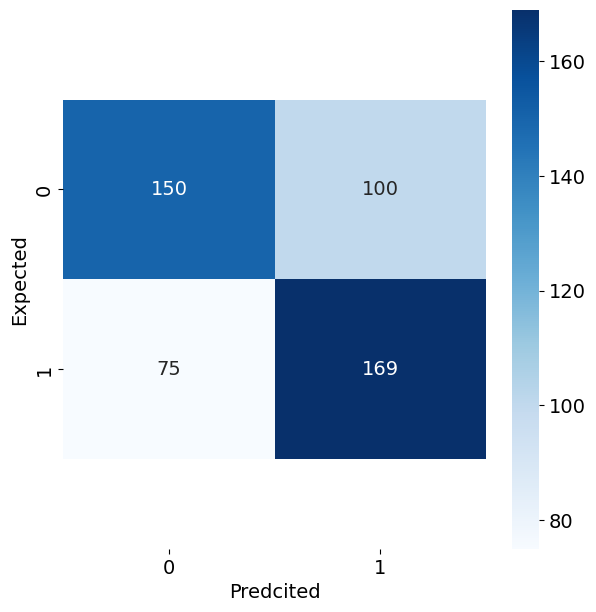

In [30]:
fig=plt.figure(figsize=(15,7))
ax1=fig.add_subplot(1,2,1)
ax2=sns.heatmap(pd.DataFrame(cnf_matrix) , annot=True , cmap='Blues' , fmt='d')
bottom,top=ax1.get_ylim()
ax1.set_ylim( bottom +0.5 , top -0.5)
plt.xlabel("Predcited")
plt.ylabel("Expected")

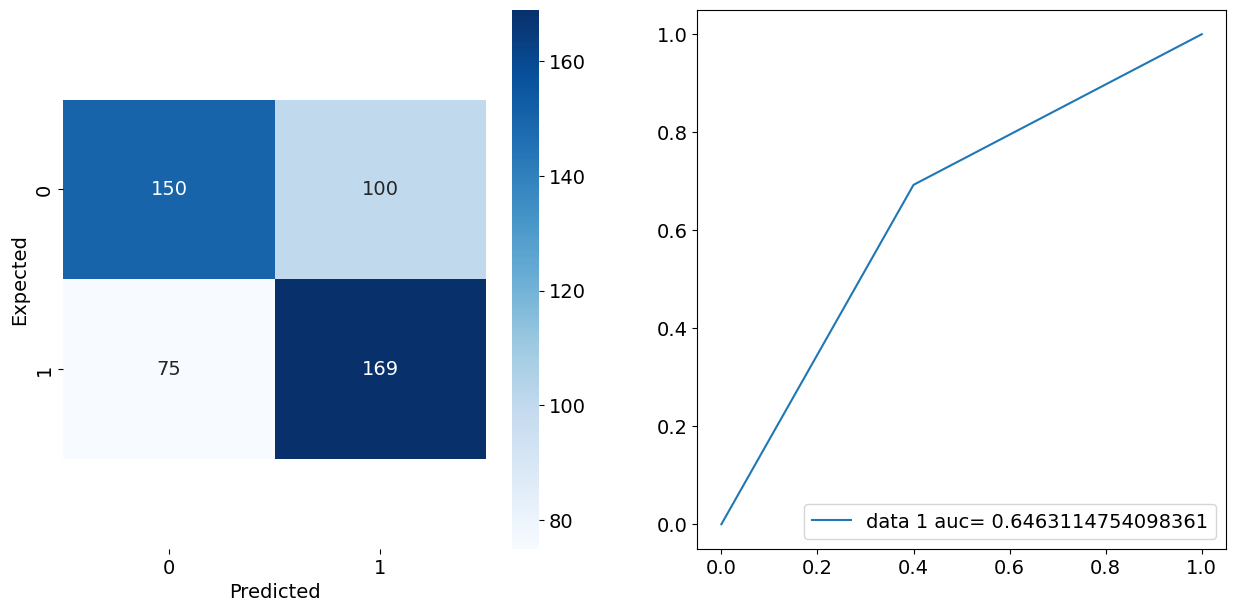

In [31]:


fig = plt.figure(figsize=(15,7))

# 🔹 Heatmap (left side)
ax1 = fig.add_subplot(1,2,1)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap='Blues', fmt='d', ax=ax1)

bottom, top = ax1.get_ylim()
ax1.set_ylim(bottom + 0.5, top - 0.5)

ax1.set_xlabel("Predicted")
ax1.set_ylabel("Expected")



# 🔹 ROC Curve (right side)
ax2 = fig.add_subplot(1,2,2)

y_pred_proba = logreg.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, predction)
auc = roc_auc_score(y_test, predction)

ax2.plot(fpr, tpr, label="data 1 auc= " + str(auc))
ax2.legend(loc=4)
plt.show()


In [32]:
data.to_csv("attrition data.csv",index = False)



In [33]:
pickle.dump(logreg, open('model.pkl', 'wb'))